# Fast swing (BS75+) vs pitch outcomes — 2025–2026 regular season

This notebook matches the **Mallitalytics pitcher card** definition of **BS75+%** (see `scripts/mallitalytics_daily_card.py` and `docs/PITCHING_CARD.md`).

### Definition (same as the card)

- **`FAST_SWING_MPH = 75`** — swings with `bat_speed >= 75` mph count as “fast” (BS75+).
- **Swing**: after `_normalize_for_card`, `description` is one of:
  `foul_bunt`, `foul`, `hit_into_play`, `swinging_strike`, `foul_tip`, `swinging_strike_blocked`, `missed_bunt`, `bunt_foul_tip`.
- **Tracked swing**: `swing` and non-null `bat_speed`.
- **BS75+%**: among **tracked swings only**, the fraction where `bat_speed >= 75`. It is **not** “% of all pitches” and **not** “% of all swings” when some swings lack bat tracking.

### Why it might matter

Fast swings can reflect timing, aggression, or pitch quality; **outcomes** (whiffs vs damage) need context, so BS75+ is a **process** signal, not a good/bad grade by itself.

### Caveats

- Denominator = swings with non-null `bat_speed` only.
- By pitch type, samples get small quickly — use minimum tracked-swing thresholds.
- BS75+ is **not** league-benchmarked on the card today (unlike whiff/chase/xwOBA columns).
- This notebook may **subsample** parquet files/rows for laptop-friendly runtime; increase env limits for full-season coverage.


In [12]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# Repo root: use __file__ when exported/run as a script, else fall back to notebook cwd.
try:
    REPO = Path(__file__).resolve().parent.parent
except NameError:
    REPO = Path.cwd()
    if REPO.name == "notebooks":
        REPO = REPO.parent

_ware = os.environ.get("MLB_WAREHOUSE_DIR", "").strip()
WAREHOUSE = Path(_ware).expanduser().resolve() if _ware else REPO / "data" / "warehouse" / "mlb"

# Aligned with scripts/mallitalytics_daily_card.py — avoid importing the card script (matplotlib, CLI).
FAST_SWING_MPH = 75
SWING_CODES = {
    "foul_bunt",
    "foul",
    "hit_into_play",
    "swinging_strike",
    "foul_tip",
    "swinging_strike_blocked",
    "missed_bunt",
    "bunt_foul_tip",
}
WHIFF_CODES = {"swinging_strike", "foul_tip", "swinging_strike_blocked"}

SEASONS = (2025, 2026)
STAGE = "regular_season"

MAX_PARQUET_FILES = int(os.environ.get("FAST_SWING_STUDY_MAX_FILES", "120"))
MAX_ROWS = int(os.environ.get("FAST_SWING_STUDY_MAX_ROWS", "400000"))
RANDOM_STATE = 42

print("WAREHOUSE:", WAREHOUSE)
print("MAX_PARQUET_FILES:", MAX_PARQUET_FILES, "MAX_ROWS:", MAX_ROWS)


WAREHOUSE: /Users/gilrojasb/Desktop/Mallitalytics_VS/MLB/data/warehouse/mlb
MAX_PARQUET_FILES: 120 MAX_ROWS: 400000


In [13]:
def discover_parquet_paths(warehouse: Path, seasons: tuple[int, ...], stage: str) -> list[Path]:
    out: list[Path] = []
    for yr in seasons:
        d = warehouse / str(yr) / stage / "pitches_enriched"
        if not d.is_dir():
            continue
        out.extend(sorted(d.glob("*.parquet")))
    return out


def normalize_description_series(s: pd.Series) -> pd.Series:
    """Mirror _normalize_for_card() on description."""
    d = s.astype(str).str.strip().str.lower().str.replace(" ", "_", regex=False).str.replace(",", "")
    bip_like = d.str.contains("in_play|hit_into_play", na=False, regex=True)
    return d.where(~bip_like, "hit_into_play")


def add_swing_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["description"] = normalize_description_series(df["description"])
    df["swing"] = df["description"].isin(SWING_CODES)
    df["whiff"] = df["description"].isin(WHIFF_CODES)
    df["is_bip"] = df["description"] == "hit_into_play"
    df["tracked_swing"] = df["swing"] & df["bat_speed"].notna()
    df["fast_swing"] = df["tracked_swing"] & (df["bat_speed"] >= FAST_SWING_MPH)
    df["slow_tracked"] = df["tracked_swing"] & (df["bat_speed"] < FAST_SWING_MPH)
    if "launch_speed" in df.columns:
        df["hard_hit"] = (df["launch_speed"] >= 95.0) & df["is_bip"]
    else:
        df["hard_hit"] = False
    if "estimated_woba_using_speedangle" in df.columns:
        df["xwoba"] = df["estimated_woba_using_speedangle"]
    else:
        df["xwoba"] = np.nan
    return df


COLS = [
    "description",
    "pitch_type",
    "bat_speed",
    "estimated_woba_using_speedangle",
    "launch_speed",
]

paths = discover_parquet_paths(WAREHOUSE, SEASONS, STAGE)
print(f"Found {len(paths)} parquet files under {SEASONS} {STAGE}")

if not paths:
    raise SystemExit(
        "No parquet files. Sync warehouse (e.g. Google Drive) or set MLB_WAREHOUSE_DIR."
    )

rng = np.random.default_rng(RANDOM_STATE)
if len(paths) > MAX_PARQUET_FILES:
    paths = sorted(rng.choice(paths, size=MAX_PARQUET_FILES, replace=False))
    print(f"Subsampled to {len(paths)} files for runtime.")

import pyarrow.parquet as pq

chunks: list[pd.DataFrame] = []
for p in paths:
    try:
        names = set(pq.ParquetFile(p).schema.names)
        use = [c for c in COLS if c in names]
        if "bat_speed" not in use or "description" not in use:
            continue
        chunks.append(pd.read_parquet(p, columns=use))
    except Exception:
        continue

if not chunks:
    raise SystemExit("No readable chunks with bat_speed + description.")

raw = pd.concat(chunks, ignore_index=True)
raw["pitch_type"] = raw.get("pitch_type", pd.Series(index=raw.index)).fillna("UN").astype(str)
if len(raw) > MAX_ROWS:
    raw = raw.sample(n=MAX_ROWS, random_state=RANDOM_STATE)
    print(f"Sampled to n={len(raw):,} rows")

df = add_swing_features(raw)
print("rows:", len(df), "cols:", list(df.columns))
df.head(3)


Found 2606 parquet files under (2025, 2026) regular_season
Subsampled to 120 files for runtime.
rows: 35629 cols: ['description', 'pitch_type', 'bat_speed', 'estimated_woba_using_speedangle', 'launch_speed', 'swing', 'whiff', 'is_bip', 'tracked_swing', 'fast_swing', 'slow_tracked', 'hard_hit', 'xwoba']


,description,pitch_type,bat_speed,estimated_woba_using_speedangle,launch_speed,swing,whiff,is_bip,tracked_swing,fast_swing,slow_tracked,hard_hit,xwoba
0,hit_into_play,FF,79.5,0.096,93.3,True,False,True,True,True,False,False,0.096
1,ball,CH,NaN,NaN,NaN,False,False,False,False,False,False,False,NaN
2,ball,FF,NaN,NaN,NaN,False,False,False,False,False,False,False,NaN


## 1) Overall: tracked swings and BS75+ rate


In [14]:
n_pitch = len(df)
n_swing = int(df["swing"].sum())
n_tracked = int(df["tracked_swing"].sum())
pct_tracked_of_swings = n_tracked / n_swing if n_swing else float("nan")
bs75_share_on_tracked = (
    float(df.loc[df["tracked_swing"], "fast_swing"].mean()) if n_tracked else float("nan")
)

pd.Series(
    {
        "pitches": n_pitch,
        "swings": n_swing,
        "tracked_swings": n_tracked,
        "pct_swings_tracked": pct_tracked_of_swings,
        "BS75_plus_share_on_tracked": bs75_share_on_tracked,
    }
)


pitches                       35629.000000
swings                        16672.000000
tracked_swings                15963.000000
pct_swings_tracked                0.957474
BS75_plus_share_on_tracked        0.230721
dtype: float64

## 2) Outcomes: fast vs slower tracked swings (pitch-level)

Compare whiff rate, BIP rate, mean xwOBA on BIP, and hard-hit rate on BIP.


In [15]:
ts = df[df["tracked_swing"]].copy()
fast = ts[ts["fast_swing"]]
slow = ts[ts["slow_tracked"]]


def summarize(label: str, g: pd.DataFrame) -> dict:
    if len(g) == 0:
        return {"group": label, "n": 0}
    bip = g[g["is_bip"]]
    return {
        "group": label,
        "n_tracked_swings": len(g),
        "whiff_rate": float(g["whiff"].mean()),
        "bip_rate": float(g["is_bip"].mean()),
        "mean_xwoba_on_bip": float(bip["xwoba"].mean()) if len(bip) else float("nan"),
        "hard_hit_rate_on_bip": float(bip["hard_hit"].mean()) if len(bip) else float("nan"),
    }


outcome_cmp = pd.DataFrame(
    [summarize("fast (>=75 mph)", fast), summarize("slower (<75 mph)", slow)]
)
outcome_cmp


,group,n_tracked_swings,whiff_rate,bip_rate,mean_xwoba_on_bip,hard_hit_rate_on_bip
0,fast (>=75 mph),3683,0.237307,0.418137,0.470184,0.564286
1,slower (<75 mph),12280,0.251547,0.350977,0.330322,0.346172


## 3) By pitch type — BS75+ vs outcomes (min tracked swings)

Rates use **pitches** as denominators for whiff/BIP (aligned with arsenal table spirit). BS75+ uses **tracked swings** only.


In [16]:
MIN_TRACKED = 800

rows = []
for pt, g in ts.groupby("pitch_type"):
    if len(g) < MIN_TRACKED:
        continue
    bip = g[g["is_bip"]]
    rows.append(
        {
            "pitch_type": pt,
            "n_tracked": len(g),
            "bs75_share": float(g["fast_swing"].mean()),
            "whiff_rate": float(g["whiff"].mean()),
            "bip_rate": float(g["is_bip"].mean()),
            "mean_xwoba_bip": float(bip["xwoba"].mean()) if len(bip) else np.nan,
            "hard_hit_rate_bip": float(bip["hard_hit"].mean()) if len(bip) else np.nan,
        }
    )

by_pt = pd.DataFrame(rows).sort_values("n_tracked", ascending=False)
by_pt.head(20)


,pitch_type,n_tracked,bs75_share,whiff_rate,bip_rate,mean_xwoba_bip,hard_hit_rate_bip
3,FF,5038,0.203057,0.210599,0.335054,0.387923,0.444313
4,SI,2526,0.244260,0.142518,0.461203,0.355786,0.445494
5,SL,2275,0.236044,0.339341,0.352088,0.369799,0.387016
0,CH,1580,0.247468,0.275949,0.388608,0.336009,0.356678
2,FC,1412,0.266997,0.231586,0.352691,0.388107,0.379518
6,ST,1125,0.225778,0.320889,0.336000,0.352826,0.328042
1,CU,967,0.210962,0.290589,0.354705,0.356089,0.355685


## 4) Fast vs slow within each pitch type (where n is large enough)

Whiff rate difference (fast − slow) on tracked swings; negative means more whiffs on slower swings.


In [17]:
MIN_PER_TYPE = 400
delta_rows = []
for pt, g in ts.groupby("pitch_type"):
    f = g[g["fast_swing"]]
    sl = g[g["slow_tracked"]]
    if len(f) < MIN_PER_TYPE or len(sl) < MIN_PER_TYPE:
        continue
    delta_rows.append(
        {
            "pitch_type": pt,
            "n_fast": len(f),
            "n_slow": len(sl),
            "whiff_fast": float(f["whiff"].mean()),
            "whiff_slow": float(sl["whiff"].mean()),
            "whiff_diff_fast_minus_slow": float(f["whiff"].mean() - sl["whiff"].mean()),
        }
    )

delta_df = pd.DataFrame(delta_rows).sort_values("whiff_diff_fast_minus_slow")
delta_df


,pitch_type,n_fast,n_slow,whiff_fast,whiff_slow,whiff_diff_fast_minus_slow
2,SL,537,1738,0.303538,0.350403,-0.046865
1,SI,617,1909,0.162075,0.136197,0.025878
0,FF,1023,4015,0.232649,0.204981,0.027668


## 5) Correlation-style view (tracked swings)

Point-biserial correlation of `fast_swing` with whiff / BIP; xwOBA on BIP rows only.


In [18]:
sub = ts.copy()
sub["whiff_i"] = sub["whiff"].astype(int)
sub["bip_i"] = sub["is_bip"].astype(int)
sub["fast_i"] = sub["fast_swing"].astype(int)

from IPython.display import display

print("Tracked swings — correlation matrix:")
display(sub[["fast_i", "whiff_i", "bip_i"]].corr())

sub_x = sub[sub["is_bip"] & sub["xwoba"].notna()]
if len(sub_x) > 200:
    print("On BIP with xwOBA — correlation:")
    display(sub_x[["fast_i", "xwoba"]].corr())
else:
    print("Not enough BIP+xwOBA rows in sample.")


Tracked swings — correlation matrix:


,fast_i,whiff_i,bip_i
fast_i,1.000000,-0.013888,0.058721
whiff_i,-0.013888,1.000000,-0.437078
bip_i,0.058721,-0.437078,1.000000


On BIP with xwOBA — correlation:


,fast_i,xwoba
fast_i,1.000000,0.159957
xwoba,0.159957,1.000000


## 6) Visuals


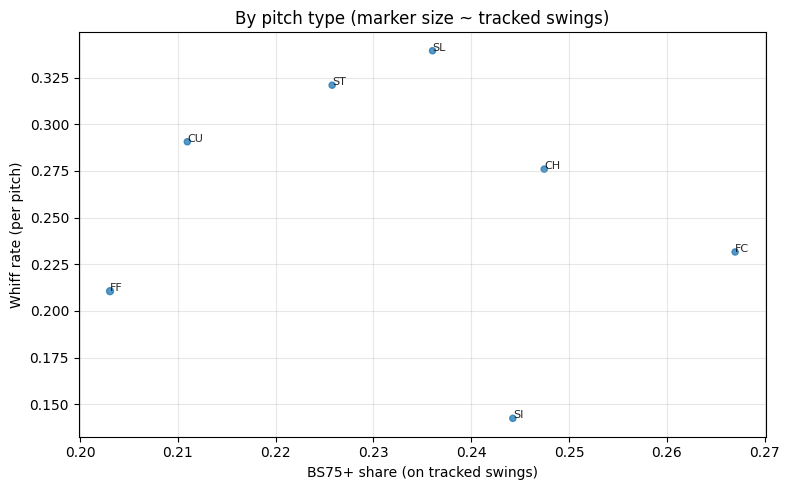

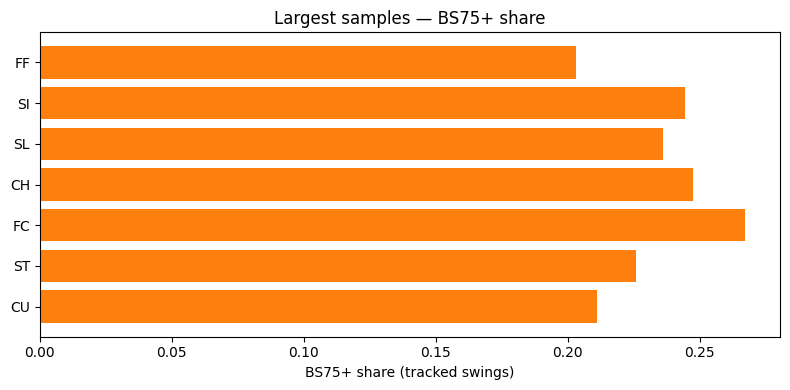

In [19]:
import matplotlib.pyplot as plt

if len(by_pt) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        by_pt["bs75_share"],
        by_pt["whiff_rate"],
        s=np.clip(by_pt["n_tracked"] / 200, 20, 200),
        alpha=0.75,
        c="tab:blue",
    )
    for _, r in by_pt.iterrows():
        ax.annotate(
            r["pitch_type"],
            (r["bs75_share"], r["whiff_rate"]),
            fontsize=8,
            alpha=0.85,
        )
    ax.set_xlabel("BS75+ share (on tracked swings)")
    ax.set_ylabel("Whiff rate (per pitch)")
    ax.set_title("By pitch type (marker size ~ tracked swings)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    top = by_pt.sort_values("n_tracked", ascending=False).head(12)
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.barh(top["pitch_type"][::-1], top["bs75_share"][::-1], color="tab:orange")
    ax2.set_xlabel("BS75+ share (tracked swings)")
    ax2.set_title("Largest samples — BS75+ share")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough per-pitch-type rows; lower MIN_TRACKED or raise MAX_FILES/MAX_ROWS.")


## 7) Implications for pitcher-card copy

- **What BS75+% captures**: Among Statcast-tracked swings, how often bat speed was **≥ 75 mph** — a simple “fast swing” rate, not contact quality by itself.
- **Do not overread**: High BS75+ is not automatically bad (whiffs) or good (damage); pair with **whiff%**, **xwOBA**, chase, and pitch shape.
- **Small samples**: Rare pitch types and single games can move BS75+ a lot; the card shows per-pitch-type BS75+ without a hard minimum — treat thin types cautiously.
- **Benchmark gap**: Until league-relative BS75+ exists, use it as **context** next to outcomes, not as a standalone headline number.

**Repro**: `MLB_WAREHOUSE_DIR=...` and optionally `FAST_SWING_STUDY_MAX_FILES`, `FAST_SWING_STUDY_MAX_ROWS` for fuller 2025–2026 coverage.


Found 2606 parquet files
Subsampled to 200 files
Loaded 58,664 rows from 200 files

Tracked swings: 27,022  |  BIP with xwOBA: 9,794

── xwOBA by 2-mph bat speed bin ──
bin_mid  n_bip  mean_xwoba  hard_hit_rt
   55.0     45    0.202889     0.000000
   57.0     65    0.218385     0.015385
   59.0     97    0.267175     0.000000
   61.0    182    0.248019     0.032967
   63.0    305    0.267561     0.101639
   65.0    511    0.249125     0.162427
   67.0    854    0.303450     0.277518
   69.0   1210    0.327262     0.344628
   71.0   1524    0.356461     0.420604
   73.0   1606    0.380025     0.472603
   75.0   1394    0.415356     0.522956
   77.0    945    0.455873     0.541799
   79.0    544    0.483084     0.549632
   81.0    247    0.511144     0.627530
   83.0    108    0.477714     0.546296

Estimated inflection point: ~73.0 mph
Card threshold (BS75): 75 mph
Gap: -2.0 mph — threshold looks well-calibrated


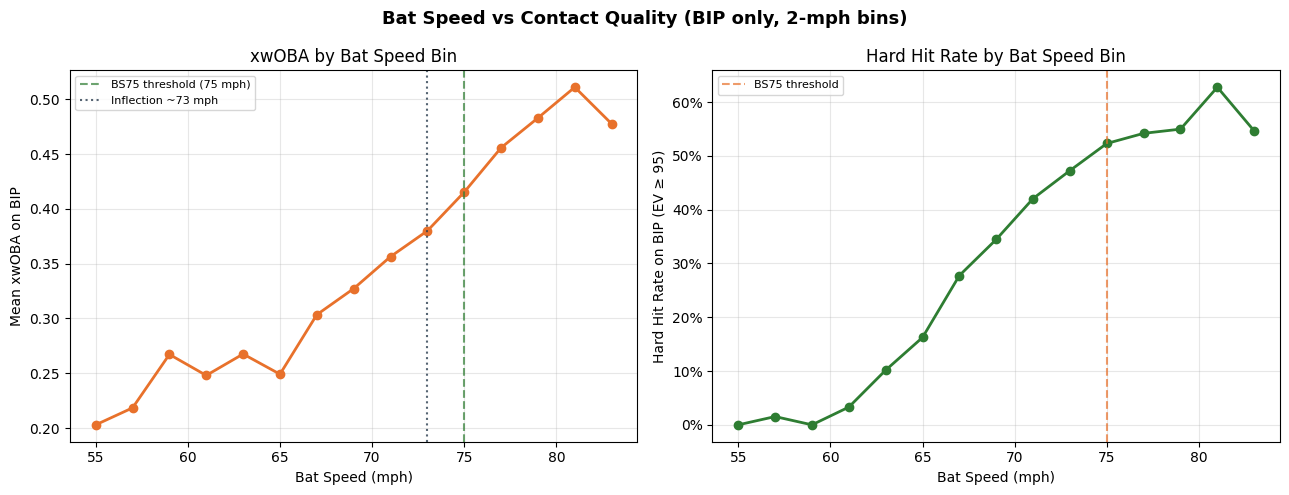

Saved → bat_speed_continuous.png
'count' column not found — skipping section 2


In [21]:
"""
bat_speed_continuous.py
Analyzes bat speed as a continuous variable against xwOBA on BIP.
Finds the inflection point where bat speed starts predicting damage.
"""

from __future__ import annotations
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Config ──────────────────────────────────────────────────────────────────
try:
    REPO = Path(__file__).resolve().parent.parent
except NameError:
    REPO = Path.cwd()
    if REPO.name == "notebooks":
        REPO = REPO.parent

_ware = os.environ.get("MLB_WAREHOUSE_DIR", "").strip()
WAREHOUSE = Path(_ware).expanduser().resolve() if _ware else REPO / "data" / "warehouse" / "mlb"
SEASONS = (2025, 2026)
STAGE = "regular_season"
MAX_FILES = int(os.environ.get("BAT_SPEED_STUDY_MAX_FILES", "200"))
RANDOM_STATE = 42
MIN_BIP_IN_BIN = 30  # minimum BIP per bat-speed bucket to plot
FAST_SWING_MPH = 75  # keep aligned with card definition

SWING_CODES = {
    "foul_bunt", "foul", "hit_into_play", "swinging_strike",
    "foul_tip", "swinging_strike_blocked", "missed_bunt", "bunt_foul_tip",
}
WHIFF_CODES = {"swinging_strike", "foul_tip", "swinging_strike_blocked"}

COLS = ["description", "pitch_type", "bat_speed",
        "estimated_woba_using_speedangle", "launch_speed", "count"]


# ── Helpers ──────────────────────────────────────────────────────────────────
def discover_paths(warehouse: Path, seasons: tuple, stage: str) -> list[Path]:
    out = []
    for yr in seasons:
        d = warehouse / str(yr) / stage / "pitches_enriched"
        if d.is_dir():
            out.extend(sorted(d.glob("*.parquet")))
    return out


def load_data(paths: list[Path], max_files: int) -> pd.DataFrame:
    import pyarrow.parquet as pq
    rng = np.random.default_rng(RANDOM_STATE)
    if len(paths) > max_files:
        paths = sorted(rng.choice(paths, size=max_files, replace=False))
        print(f"Subsampled to {len(paths)} files")

    chunks = []
    for p in paths:
        try:
            names = set(pq.ParquetFile(p).schema.names)
            use = [c for c in COLS if c in names]
            if not {"bat_speed", "description"}.issubset(use):
                continue
            chunks.append(pd.read_parquet(p, columns=use))
        except Exception:
            continue

    df = pd.concat(chunks, ignore_index=True)
    print(f"Loaded {len(df):,} rows from {len(chunks)} files")
    return df


def prep(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize and add swing flags — same logic as card."""
    df = df.copy()
    desc = df["description"].astype(str).str.strip().str.lower().str.replace(" ", "_", regex=False)
    desc = desc.where(~desc.str.contains("in_play|hit_into_play", regex=True), "hit_into_play")
    df["description"] = desc
    df["swing"]         = desc.isin(SWING_CODES)
    df["whiff"]         = desc.isin(WHIFF_CODES)
    df["is_bip"]        = desc == "hit_into_play"
    df["tracked_swing"] = df["swing"] & df["bat_speed"].notna()
    df["fast_swing"]    = df["tracked_swing"] & (df["bat_speed"] >= FAST_SWING_MPH)
    df["hard_hit"]      = (df["launch_speed"] >= 95.0) & df["is_bip"]
    df["xwoba"]         = df.get("estimated_woba_using_speedangle", np.nan)
    return df


# ── Analysis ─────────────────────────────────────────────────────────────────
def section1_xwoba_by_bs_bins(bip: pd.DataFrame) -> pd.DataFrame:
    """
    xwOBA and hard-hit rate in 2-mph bat speed bins.
    This is the core continuous analysis.
    """
    bip = bip.copy()
    bip["bs_bin"] = pd.cut(bip["bat_speed"], bins=np.arange(40, 85, 2), right=False)
    grp = bip.groupby("bs_bin", observed=True).agg(
        n_bip       = ("xwoba", "count"),
        mean_xwoba  = ("xwoba", "mean"),
        hard_hit_rt = ("hard_hit", "mean"),
    ).reset_index()
    grp = grp[grp["n_bip"] >= MIN_BIP_IN_BIN]
    grp["bin_mid"] = grp["bs_bin"].apply(lambda x: x.mid)
    return grp


def section2_count_by_bs(ts: pd.DataFrame) -> pd.DataFrame:
    """
    Fast swing rate by count (0-0, 1-0, 3-1 vs 0-2, 1-2).
    Validates whether fast_swing is a 'sitting on a pitch' signal.
    """
    if "count" not in ts.columns:
        print("'count' column not found — skipping section 2")
        return pd.DataFrame()

    ts = ts.copy()
    # Parse count string e.g. "1-2" → balls=1, strikes=2
    split = ts["count"].astype(str).str.extract(r"(\d)-(\d)")
    ts["balls"]   = pd.to_numeric(split[0], errors="coerce")
    ts["strikes"] = pd.to_numeric(split[1], errors="coerce")

    def tag_count(row):
        b, s = row["balls"], row["strikes"]
        if pd.isna(b) or pd.isna(s):
            return "unknown"
        if s == 2:
            return "two_strike"
        if b >= 2 and s == 0:
            return "hitter_count"
        if b == 0 and s == 0:
            return "first_pitch"
        return "neutral"

    ts["count_type"] = ts.apply(tag_count, axis=1)
    grp = ts.groupby("count_type").agg(
        n           = ("fast_swing", "count"),
        fast_pct    = ("fast_swing", "mean"),
        whiff_rate  = ("whiff", "mean"),
    ).reset_index()
    return grp.sort_values("fast_pct", ascending=False)


def section3_inflection_point(bins: pd.DataFrame) -> float:
    """
    Simple inflection detection: find bat speed where xwOBA first
    crosses the 50th pct of the xwOBA range (crude but interpretable).
    """
    if bins.empty:
        return float("nan")
    lo, hi = bins["mean_xwoba"].min(), bins["mean_xwoba"].max()
    threshold = lo + (hi - lo) * 0.5
    above = bins[bins["mean_xwoba"] >= threshold]
    return float(above["bin_mid"].min()) if not above.empty else float("nan")


# ── Plots ─────────────────────────────────────────────────────────────────────
def plot_continuous(bins: pd.DataFrame, inflection: float) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bat Speed vs Contact Quality (BIP only, 2-mph bins)", fontsize=13, fontweight="bold")

    # xwOBA
    ax1.plot(bins["bin_mid"], bins["mean_xwoba"], "o-", color="#E8712B", lw=2)
    ax1.axvline(FAST_SWING_MPH, ls="--", color="#2E7D32", alpha=0.7, label=f"BS75 threshold ({FAST_SWING_MPH} mph)")
    if not np.isnan(inflection):
        ax1.axvline(inflection, ls=":", color="#2C3E50", alpha=0.8, label=f"Inflection ~{inflection:.0f} mph")
    ax1.set_xlabel("Bat Speed (mph)")
    ax1.set_ylabel("Mean xwOBA on BIP")
    ax1.set_title("xwOBA by Bat Speed Bin")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Hard-hit rate
    ax2.plot(bins["bin_mid"], bins["hard_hit_rt"], "o-", color="#2E7D32", lw=2)
    ax2.axvline(FAST_SWING_MPH, ls="--", color="#E8712B", alpha=0.7, label=f"BS75 threshold")
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_xlabel("Bat Speed (mph)")
    ax2.set_ylabel("Hard Hit Rate on BIP (EV ≥ 95)")
    ax2.set_title("Hard Hit Rate by Bat Speed Bin")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("bat_speed_continuous.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → bat_speed_continuous.png")


def plot_count_fast_pct(grp: pd.DataFrame) -> None:
    if grp.empty:
        return
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = {"hitter_count": "#E8712B", "first_pitch": "#F0A830",
              "neutral": "#66BB6A", "two_strike": "#2C3E50", "unknown": "#5D6D7E"}
    bars = ax.barh(grp["count_type"], grp["fast_pct"],
                   color=[colors.get(c, "#5D6D7E") for c in grp["count_type"]])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Fast Swing Rate (BS75+)")
    ax.set_title("Fast Swing Rate by Count Type\n(Is fast_swing a 'sitting on pitch' signal?)")
    ax.grid(True, alpha=0.3, axis="x")
    for bar, val in zip(bars, grp["fast_pct"]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("fast_swing_by_count.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → fast_swing_by_count.png")


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    paths = discover_paths(WAREHOUSE, SEASONS, STAGE)
    print(f"Found {len(paths)} parquet files")

    raw = load_data(paths, MAX_FILES)
    df  = prep(raw)

    ts  = df[df["tracked_swing"]].copy()
    bip = ts[ts["is_bip"] & ts["xwoba"].notna()].copy()

    print(f"\nTracked swings: {len(ts):,}  |  BIP with xwOBA: {len(bip):,}")

    # Section 1 — continuous bat speed vs contact quality
    bins = section1_xwoba_by_bs_bins(bip)
    print("\n── xwOBA by 2-mph bat speed bin ──")
    print(bins[["bin_mid", "n_bip", "mean_xwoba", "hard_hit_rt"]].to_string(index=False))

    inflection = section3_inflection_point(bins)
    print(f"\nEstimated inflection point: ~{inflection:.1f} mph")
    print(f"Card threshold (BS75): {FAST_SWING_MPH} mph")
    if not np.isnan(inflection):
        gap = inflection - FAST_SWING_MPH
        print(f"Gap: {gap:+.1f} mph — ", end="")
        print("threshold may be too low" if gap > 2 else
              "threshold may be too high" if gap < -2 else
              "threshold looks well-calibrated")

    plot_continuous(bins, inflection)

    # Section 2 — fast swing rate by count
    count_grp = section2_count_by_bs(ts)
    if not count_grp.empty:
        print("\n── Fast swing rate by count type ──")
        print(count_grp.to_string(index=False))
        plot_count_fast_pct(count_grp)


if __name__ == "__main__":
    main()
    

Found 2606 parquet files
Subsampled to 200 files
Loaded 58,664 rows from 200 files
Tracked swings: 27,022

── Fast swing rate by individual count ──
count  n_tracked  fast_pct   mean_bs  whiff_rate  xwoba_bip  hard_hit_bip
  0-0       4605  0.264495 69.734354    0.261455   0.383984      0.440154
  1-0       2395  0.320251 71.256033    0.258455   0.387147      0.444319
  2-0        768  0.355469 72.240495    0.242188   0.430258      0.535849
  3-1        672  0.349702 72.353720    0.206845   0.426955      0.517928
  0-1       3667  0.200709 69.094219    0.271339   0.374795      0.391913
  1-1       3053  0.242057 70.192237    0.259089   0.372569      0.417108
  2-1       1722  0.279907 71.151161    0.222997   0.368529      0.436937
  3-2       2134  0.251640 70.799485    0.170103   0.374175      0.415991
  0-2       1897  0.124407 67.347865    0.285187   0.336227      0.335312
  1-2       3140  0.149045 68.164682    0.268153   0.332391      0.348254
  2-2       2935  0.174106 69.252300 

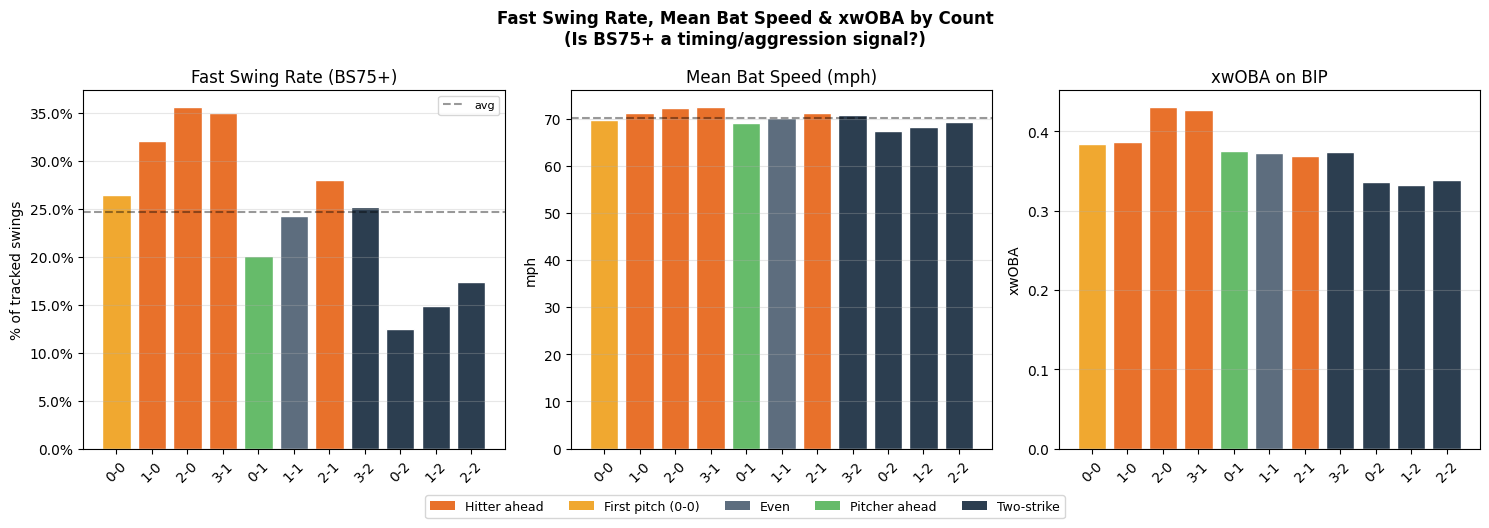

Saved → fast_swing_by_count.png


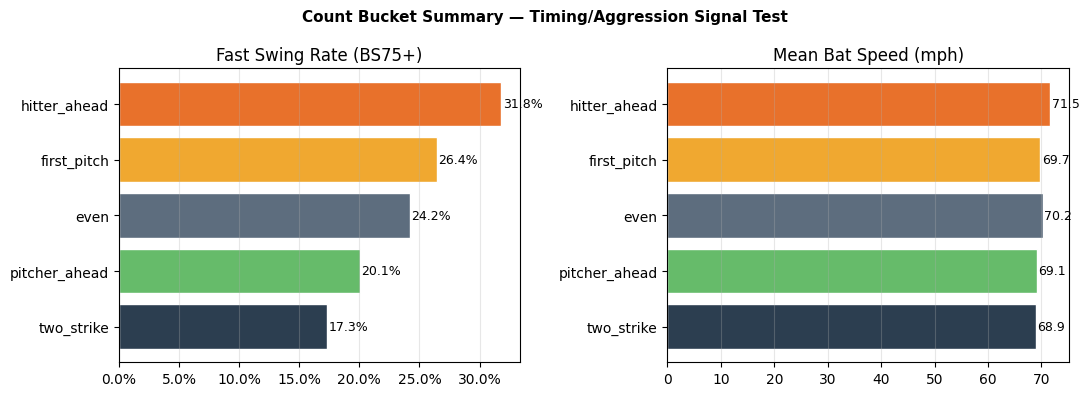

Saved → fast_swing_count_type.png


In [24]:
"""
fast_swing_by_count.py
Tests whether BS75+ clusters on hitter-favorable counts (timing/aggression signal)
vs being purely a physical trait (batter always swings fast regardless of situation).
"""

from __future__ import annotations
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Config ────────────────────────────────────────────────────────────────────
try:
    REPO = Path(__file__).resolve().parent.parent
except NameError:
    REPO = Path.cwd()
    if REPO.name == "notebooks":
        REPO = REPO.parent

_ware = os.environ.get("MLB_WAREHOUSE_DIR", "").strip()
WAREHOUSE = Path(_ware).expanduser().resolve() if _ware else REPO / "data" / "warehouse" / "mlb"
SEASONS = (2025, 2026)
STAGE = "regular_season"
MAX_FILES = int(os.environ.get("COUNT_STUDY_MAX_FILES", "200"))
RANDOM_STATE = 42
FAST_SWING_MPH = 75

SWING_CODES = {
    "foul_bunt", "foul", "hit_into_play", "swinging_strike",
    "foul_tip", "swinging_strike_blocked", "missed_bunt", "bunt_foul_tip",
}
WHIFF_CODES = {"swinging_strike", "foul_tip", "swinging_strike_blocked"}

COLS = [
    "description", "pitch_type", "bat_speed",
    "estimated_woba_using_speedangle", "launch_speed",
    "balls", "strikes",                          # count state
    "batter",                                     # for batter-level analysis
]

COUNT_ORDER = ["0-0", "1-0", "2-0", "3-0", "3-1",   # hitter counts
               "0-1", "1-1", "2-1", "3-2",            # neutral
               "0-2", "1-2", "2-2"]                   # pitcher counts


# ── Helpers ───────────────────────────────────────────────────────────────────
def discover_paths(warehouse: Path, seasons: tuple, stage: str) -> list[Path]:
    out = []
    for yr in seasons:
        d = warehouse / str(yr) / stage / "pitches_enriched"
        if d.is_dir():
            out.extend(sorted(d.glob("*.parquet")))
    return out


def load_data(paths: list[Path], max_files: int) -> pd.DataFrame:
    import pyarrow.parquet as pq
    rng = np.random.default_rng(RANDOM_STATE)
    if len(paths) > max_files:
        paths = sorted(rng.choice(paths, size=max_files, replace=False))
        print(f"Subsampled to {len(paths)} files")

    chunks = []
    for p in paths:
        try:
            names = set(pq.ParquetFile(p).schema.names)
            use = [c for c in COLS if c in names]
            if not {"bat_speed", "description", "balls", "strikes"}.issubset(use):
                continue
            chunks.append(pd.read_parquet(p, columns=use))
        except Exception:
            continue

    df = pd.concat(chunks, ignore_index=True)
    print(f"Loaded {len(df):,} rows from {len(chunks)} files")
    return df


def prep(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    desc = (df["description"].astype(str).str.strip().str.lower()
            .str.replace(" ", "_", regex=False))
    desc = desc.where(~desc.str.contains("in_play|hit_into_play", regex=True), "hit_into_play")
    df["description"]   = desc
    df["swing"]         = desc.isin(SWING_CODES)
    df["whiff"]         = desc.isin(WHIFF_CODES)
    df["is_bip"]        = desc == "hit_into_play"
    df["tracked_swing"] = df["swing"] & df["bat_speed"].notna()
    df["fast_swing"]    = df["tracked_swing"] & (df["bat_speed"] >= FAST_SWING_MPH)
    df["hard_hit"]      = (df.get("launch_speed", np.nan) >= 95.0) & df["is_bip"]
    df["xwoba"]         = df.get("estimated_woba_using_speedangle", np.nan)

    # Build count label
    b = pd.to_numeric(df["balls"],   errors="coerce").fillna(0).astype(int).clip(0, 3)
    s = pd.to_numeric(df["strikes"], errors="coerce").fillna(0).astype(int).clip(0, 2)
    df["count_label"] = b.astype(str) + "-" + s.astype(str)

    # Count type bucket
    def _bucket(row):
        b_, s_ = row["balls_int"], row["strikes_int"]
        if s_ == 2:
            return "two_strike"
        if b_ >= 2 and s_ == 0:
            return "hitter_ahead"
        if b_ == 3 and s_ <= 1:
            return "hitter_ahead"
        if b_ == 0 and s_ == 0:
            return "first_pitch"
        if b_ > s_:
            return "hitter_ahead"
        if s_ > b_:
            return "pitcher_ahead"
        return "even"

    df["balls_int"]   = b
    df["strikes_int"] = s
    df["count_type"]  = df[["balls_int", "strikes_int"]].apply(_bucket, axis=1)
    return df


# ── Analysis ──────────────────────────────────────────────────────────────────
def section1_by_count_label(ts: pd.DataFrame) -> pd.DataFrame:
    """Fast swing rate + mean bat speed for every individual count (0-0, 1-0, etc.)"""
    rows = []
    for count, g in ts.groupby("count_label"):
        if len(g) < 50:
            continue
        bip = g[g["is_bip"] & g["xwoba"].notna()]
        rows.append({
            "count"         : count,
            "n_tracked"     : len(g),
            "fast_pct"      : float(g["fast_swing"].mean()),
            "mean_bs"       : float(g["bat_speed"].mean()),
            "whiff_rate"    : float(g["whiff"].mean()),
            "xwoba_bip"     : float(bip["xwoba"].mean()) if len(bip) >= 10 else np.nan,
            "hard_hit_bip"  : float(bip["hard_hit"].mean()) if len(bip) >= 10 else np.nan,
        })

    df_out = pd.DataFrame(rows)
    # Sort by COUNT_ORDER, append anything not in the list at end
    ordered = [c for c in COUNT_ORDER if c in df_out["count"].values]
    rest    = [c for c in df_out["count"].values if c not in ordered]
    df_out  = df_out.set_index("count").loc[ordered + rest].reset_index()
    return df_out


def section2_by_count_type(ts: pd.DataFrame) -> pd.DataFrame:
    """Bucketed view: hitter_ahead / first_pitch / even / pitcher_ahead / two_strike"""
    rows = []
    for ct, g in ts.groupby("count_type"):
        bip = g[g["is_bip"] & g["xwoba"].notna()]
        rows.append({
            "count_type"    : ct,
            "n_tracked"     : len(g),
            "fast_pct"      : float(g["fast_swing"].mean()),
            "mean_bs"       : float(g["bat_speed"].mean()),
            "whiff_rate"    : float(g["whiff"].mean()),
            "xwoba_bip"     : float(bip["xwoba"].mean()) if len(bip) >= 20 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("fast_pct", ascending=False)


def section3_batter_variance(ts: pd.DataFrame) -> dict:
    """
    Key diagnostic: do individual batters vary their bat speed by count,
    or is bat speed essentially fixed per batter?

    If within-batter variance across counts > 0, it's a situational signal.
    If within-batter variance ≈ 0, it's purely physical trait.
    """
    if "batter" not in ts.columns:
        return {}

    # Per batter × count: mean bat speed
    bxc = (ts.groupby(["batter", "count_label"])["bat_speed"]
             .mean()
             .reset_index()
             .rename(columns={"bat_speed": "mean_bs"}))

    # Within-batter std across counts
    within = bxc.groupby("batter")["mean_bs"].std().dropna()

    # Between-batter std (batter baseline)
    between = ts.groupby("batter")["bat_speed"].mean().std()

    return {
        "median_within_batter_bs_std" : float(within.median()),
        "between_batter_bs_std"       : float(between),
        "ratio_within_over_between"   : float(within.median() / between) if between else float("nan"),
        "n_batters"                   : int(len(within)),
    }


# ── Plots ─────────────────────────────────────────────────────────────────────
def plot_by_count_label(df: pd.DataFrame) -> None:
    df = df[df["count"].isin(COUNT_ORDER)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Fast Swing Rate, Mean Bat Speed & xwOBA by Count\n"
                 "(Is BS75+ a timing/aggression signal?)", fontsize=12, fontweight="bold")

    # Color: hitter counts orange, pitcher counts teal, neutral gray
    def color(c):
        b, s = int(c[0]), int(c[2])
        if s == 2:              return "#2C3E50"   # dark — pitcher count
        if b > s:               return "#E8712B"   # orange — hitter ahead
        if b == s and b == 0:   return "#F0A830"   # gold — 0-0
        if s > b:               return "#66BB6A"   # green — pitcher ahead
        return "#5D6D7E"

    colors = [color(c) for c in df["count"]]

    # Panel 1 — fast swing %
    ax = axes[0]
    bars = ax.bar(df["count"], df["fast_pct"], color=colors, edgecolor="white")
    ax.xaxis.set_tick_params(rotation=45)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Fast Swing Rate (BS75+)")
    ax.set_ylabel("% of tracked swings")
    ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(df["fast_pct"].mean(), ls="--", color="black", alpha=0.4, label="avg")
    ax.legend(fontsize=8)

    # Panel 2 — mean bat speed
    ax = axes[1]
    ax.bar(df["count"], df["mean_bs"], color=colors, edgecolor="white")
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_title("Mean Bat Speed (mph)")
    ax.set_ylabel("mph")
    ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(df["mean_bs"].mean(), ls="--", color="black", alpha=0.4)

    # Panel 3 — xwOBA on BIP
    ax = axes[2]
    xw = df.dropna(subset=["xwoba_bip"])
    ax.bar(xw["count"], xw["xwoba_bip"], color=[color(c) for c in xw["count"]], edgecolor="white")
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_title("xwOBA on BIP")
    ax.set_ylabel("xwOBA")
    ax.grid(True, alpha=0.3, axis="y")

    # Legend patch
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#E8712B", label="Hitter ahead"),
        Patch(facecolor="#F0A830", label="First pitch (0-0)"),
        Patch(facecolor="#5D6D7E", label="Even"),
        Patch(facecolor="#66BB6A", label="Pitcher ahead"),
        Patch(facecolor="#2C3E50", label="Two-strike"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

    plt.tight_layout()
    plt.savefig("fast_swing_by_count.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → fast_swing_by_count.png")


def plot_count_type_summary(df: pd.DataFrame) -> None:
    type_order = ["hitter_ahead", "first_pitch", "even", "pitcher_ahead", "two_strike"]
    colors_map  = {
        "hitter_ahead" : "#E8712B",
        "first_pitch"  : "#F0A830",
        "even"         : "#5D6D7E",
        "pitcher_ahead": "#66BB6A",
        "two_strike"   : "#2C3E50",
    }
    df = df.set_index("count_type").reindex(type_order).reset_index().dropna(subset=["fast_pct"])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle("Count Bucket Summary — Timing/Aggression Signal Test", fontsize=11, fontweight="bold")

    for ax, (col, label, fmt) in zip(axes, [
        ("fast_pct", "Fast Swing Rate (BS75+)", "pct"),
        ("mean_bs",  "Mean Bat Speed (mph)",    "raw"),
    ]):
        bars = ax.barh(
            df["count_type"][::-1], df[col][::-1],
            color=[colors_map.get(c, "#5D6D7E") for c in df["count_type"][::-1]],
            edgecolor="white"
        )
        if fmt == "pct":
            ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title(label)
        ax.grid(True, alpha=0.3, axis="x")
        for bar, val in zip(bars, df[col][::-1]):
            if not np.isnan(val):
                txt = f"{val:.1%}" if fmt == "pct" else f"{val:.1f}"
                ax.text(val * 1.005, bar.get_y() + bar.get_height() / 2,
                        txt, va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("fast_swing_count_type.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → fast_swing_count_type.png")


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    paths = discover_paths(WAREHOUSE, SEASONS, STAGE)
    print(f"Found {len(paths)} parquet files")

    raw = load_data(paths, MAX_FILES)
    df  = prep(raw)
    ts  = df[df["tracked_swing"]].copy()

    print(f"Tracked swings: {len(ts):,}\n")

    # Section 1 — granular count breakdown
    by_count = section1_by_count_label(ts)
    print("── Fast swing rate by individual count ──")
    print(by_count.to_string(index=False))

    # Section 2 — bucketed
    by_type = section2_by_count_type(ts)
    print("\n── By count bucket ──")
    print(by_type.to_string(index=False))

    # Section 3 — batter variance (the real physical-vs-situational test)
    variance = section3_batter_variance(ts)
    if variance:
        print("\n── Batter-level bat speed variance across counts ──")
        for k, v in variance.items():
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
        ratio = variance.get("ratio_within_over_between", float("nan"))
        if not np.isnan(ratio):
            print(f"\n  Interpretation:")
            if ratio < 0.15:
                print("  → Bat speed is mostly a PHYSICAL TRAIT — low situational variation")
            elif ratio < 0.30:
                print("  → Mixed signal — some situational adjustment, mostly physical")
            else:
                print("  → Bat speed has meaningful SITUATIONAL variation — timing/aggression signal")

    # Plots
    plot_by_count_label(by_count)
    plot_count_type_summary(by_type)


if __name__ == "__main__":
    main()
    